In [3]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
from matplotlib import pyplot as plt

print_types = [
           'Car_bev/easy_R40',        'Car_bev_relaxed/easy_R40',        'Car_3d/easy_R40',        'Car_3d_relaxed/easy_R40', 
    'Pedestrian_bev/easy_R40', 'Pedestrian_bev_relaxed/easy_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d_relaxed/easy_R40',
       'Cyclist_bev/easy_R40',    'Cyclist_bev_relaxed/easy_R40',    'Cyclist_3d/easy_R40',    'Cyclist_3d_relaxed/easy_R40'
    ]


def print_tb(log_dir):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    scalar_tags = ea.Tags()['scalars']
    print(scalar_tags)

    matched_tags = [tag for tag in print_types if tag in scalar_tags]
    if matched_tags:
        n_plots = len(matched_tags)
        n_cols = 4
        n_rows = (n_plots + n_cols - 1) // n_cols
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=False)
        axs = axs.flatten() if n_plots > 1 else [axs]

        for ax in axs[n_plots:]:
            ax.axis('off')

        for ax, tag in zip(axs, matched_tags):
            data = [(s.step, s.value) for s in ea.Scalars(tag)]
            df = pd.DataFrame(data, columns=['epoch', 'perf'])
            ax.plot(df['epoch'], df['perf'], linewidth=1.5)
            ax.set_title(tag, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Performance')
            ax.grid(True, linestyle='--', alpha=0.6)

        plt.suptitle('TensorBoard Metrics', fontsize=12, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        return

    elif 'NDS' in scalar_tags:
        data = [(s.step, s.value) for s in ea.Scalars('NDS')]
        df = pd.DataFrame(data, columns=['Step', 'NDS'])
        df.plot(x='Step', y='NDS', kind='line', grid=True, title='NDS')
        plt.show()

    elif 'train/loss' in scalar_tags:
        data = [(s.step, s.value) for s in ea.Scalars('train/loss')]
        df = pd.DataFrame(data, columns=['Step', 'Loss'])
        df.plot(x='Step', y='Loss', kind='line', grid=True, title='Loss')
        plt.show()
    return
    


In [ ]:
log_test = {
    "P_D_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "P_T_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "S_D_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "S_F_def": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_T_def": {
        "K": "",
        "N": "",
        "E": "",
    },
    "P_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_E/default/eval/eval_all_default/default_0/tensorboard_val_all",
    },
    "P_T_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_N/default/eval/eval_all_default/default/tensorboard_val_all",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_F_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val_all",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_T_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/T/S_T_E/default/eval/eval_all_default/default/tensorboard_val_all",
    }
}


In [5]:
log_train = {
    "P_ftd"       :"/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_N/unfrozen_backbone_1/tensorboard",
    "S_ftd"       :"",    
    "S_focals_def":"", 
    "S_focals_ftd":"",
    }



# TEST

## SECOND (DEFAULT)

2026-08-13 15:47:33.083003: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-13 15:47:33.849428: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

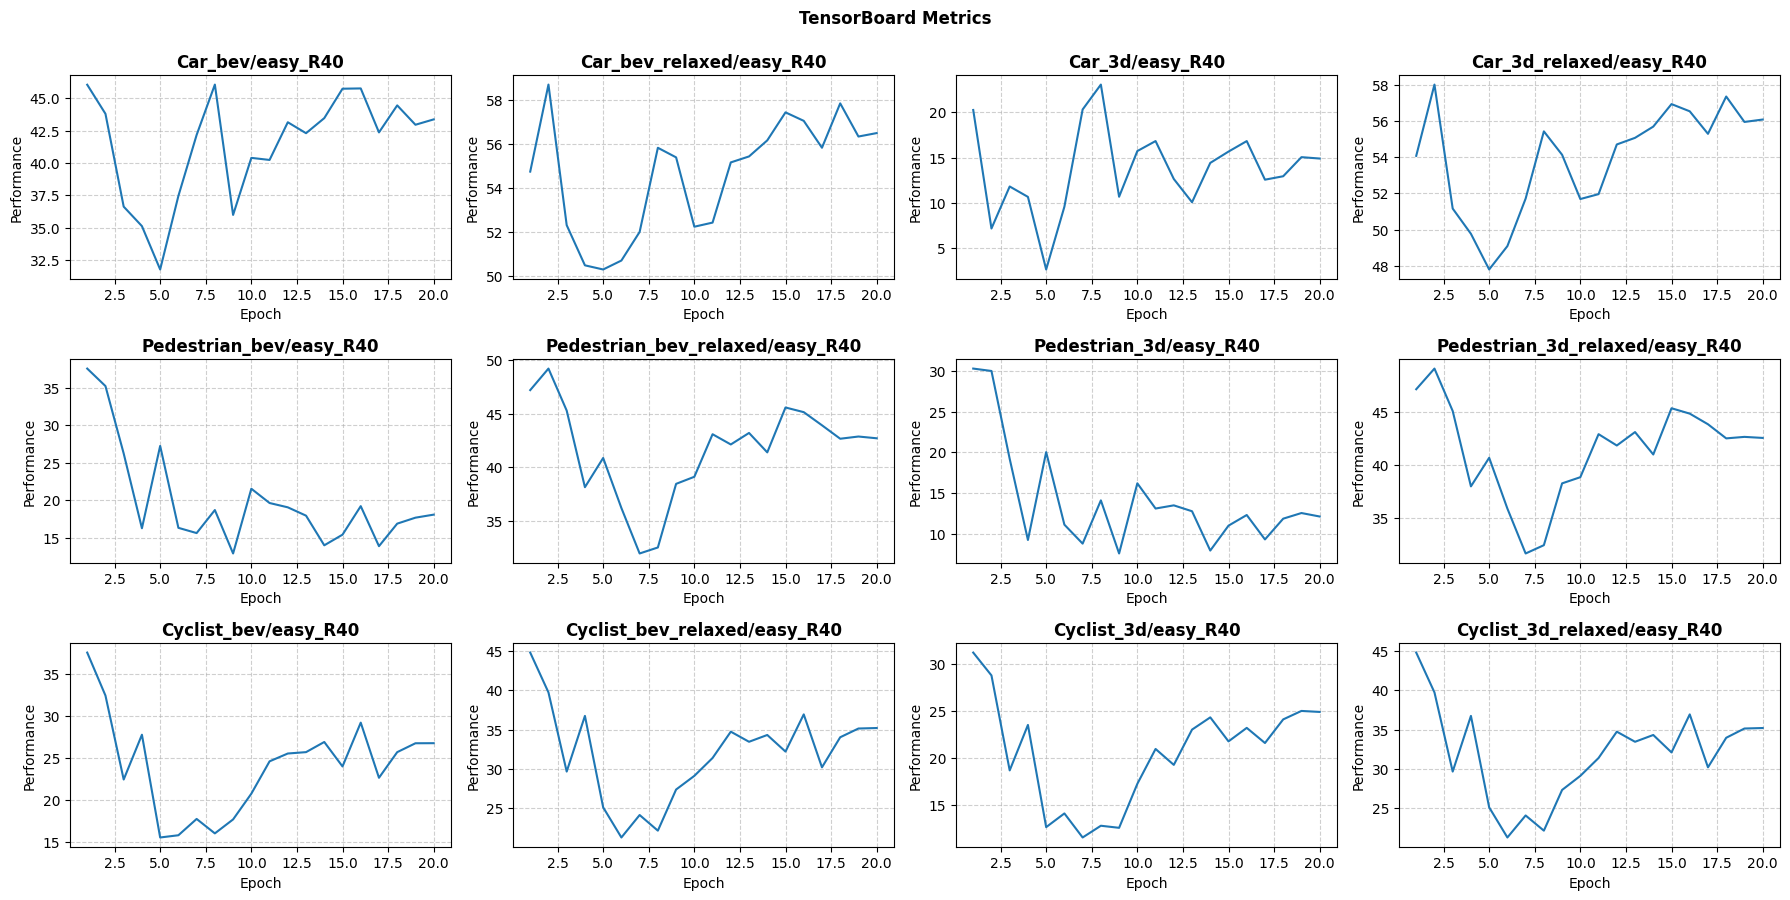

In [4]:
print_tb(log_test["S_D_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'mAP', 'NDS']


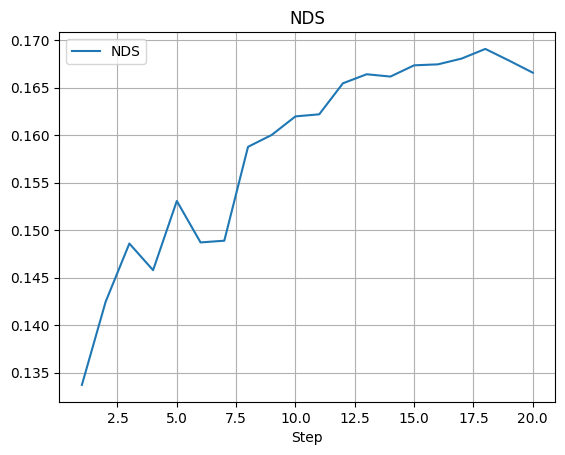

In [5]:
print_tb(log_test["S_D_ftd"]["N"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

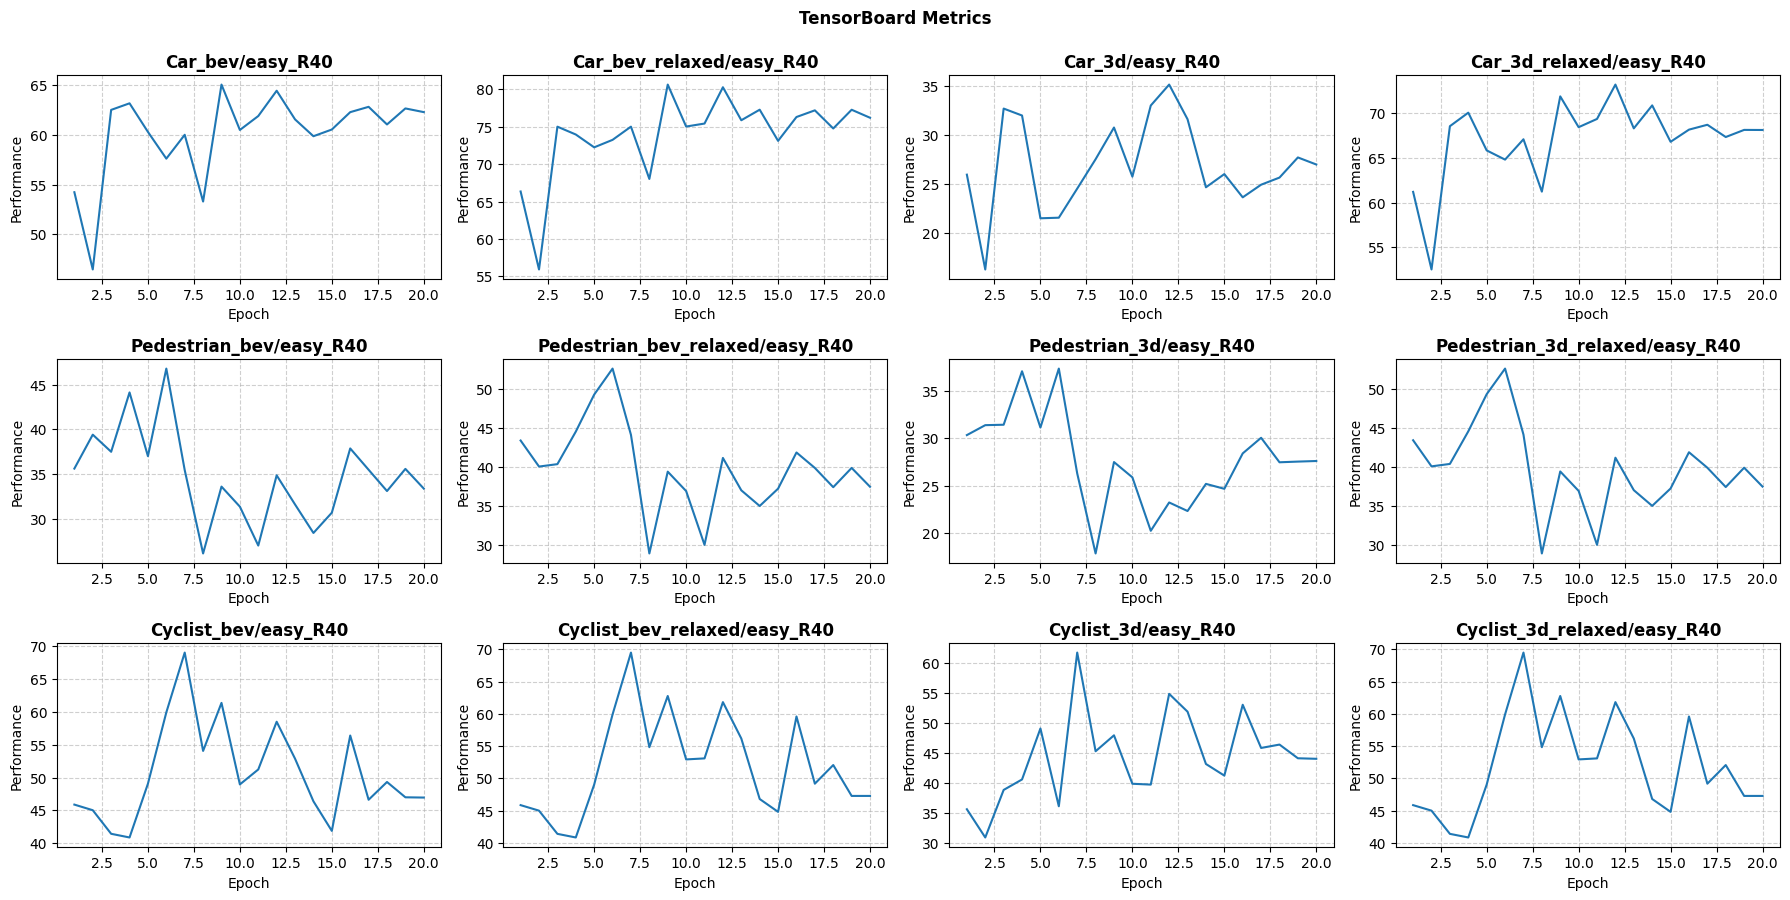

In [6]:
print_tb(log_test["S_D_ftd"]["E"])

## SECOND (FOCALS)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

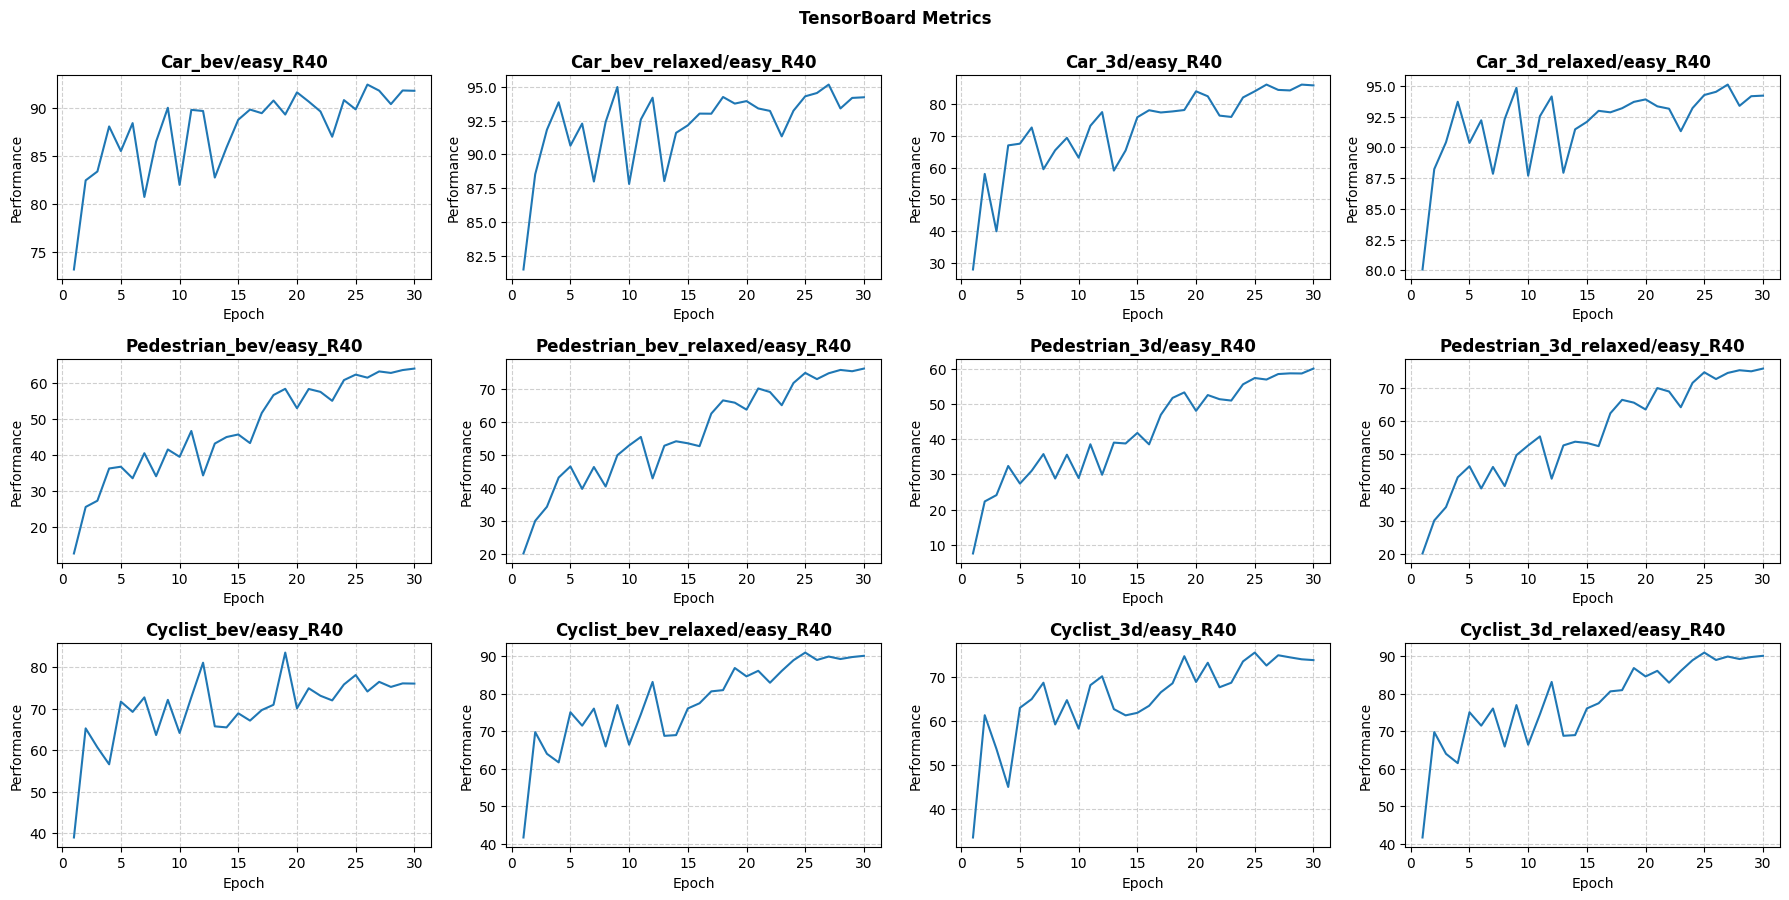

In [7]:
print_tb(log_test["S_F_def"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'mAP', 'NDS']


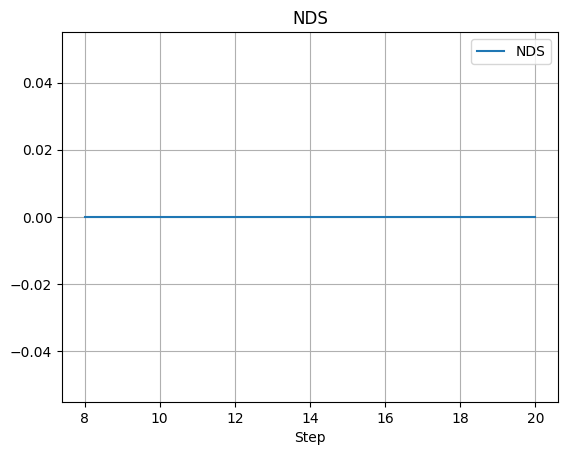

In [8]:
print_tb(log_test["S_F_def"]["N"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

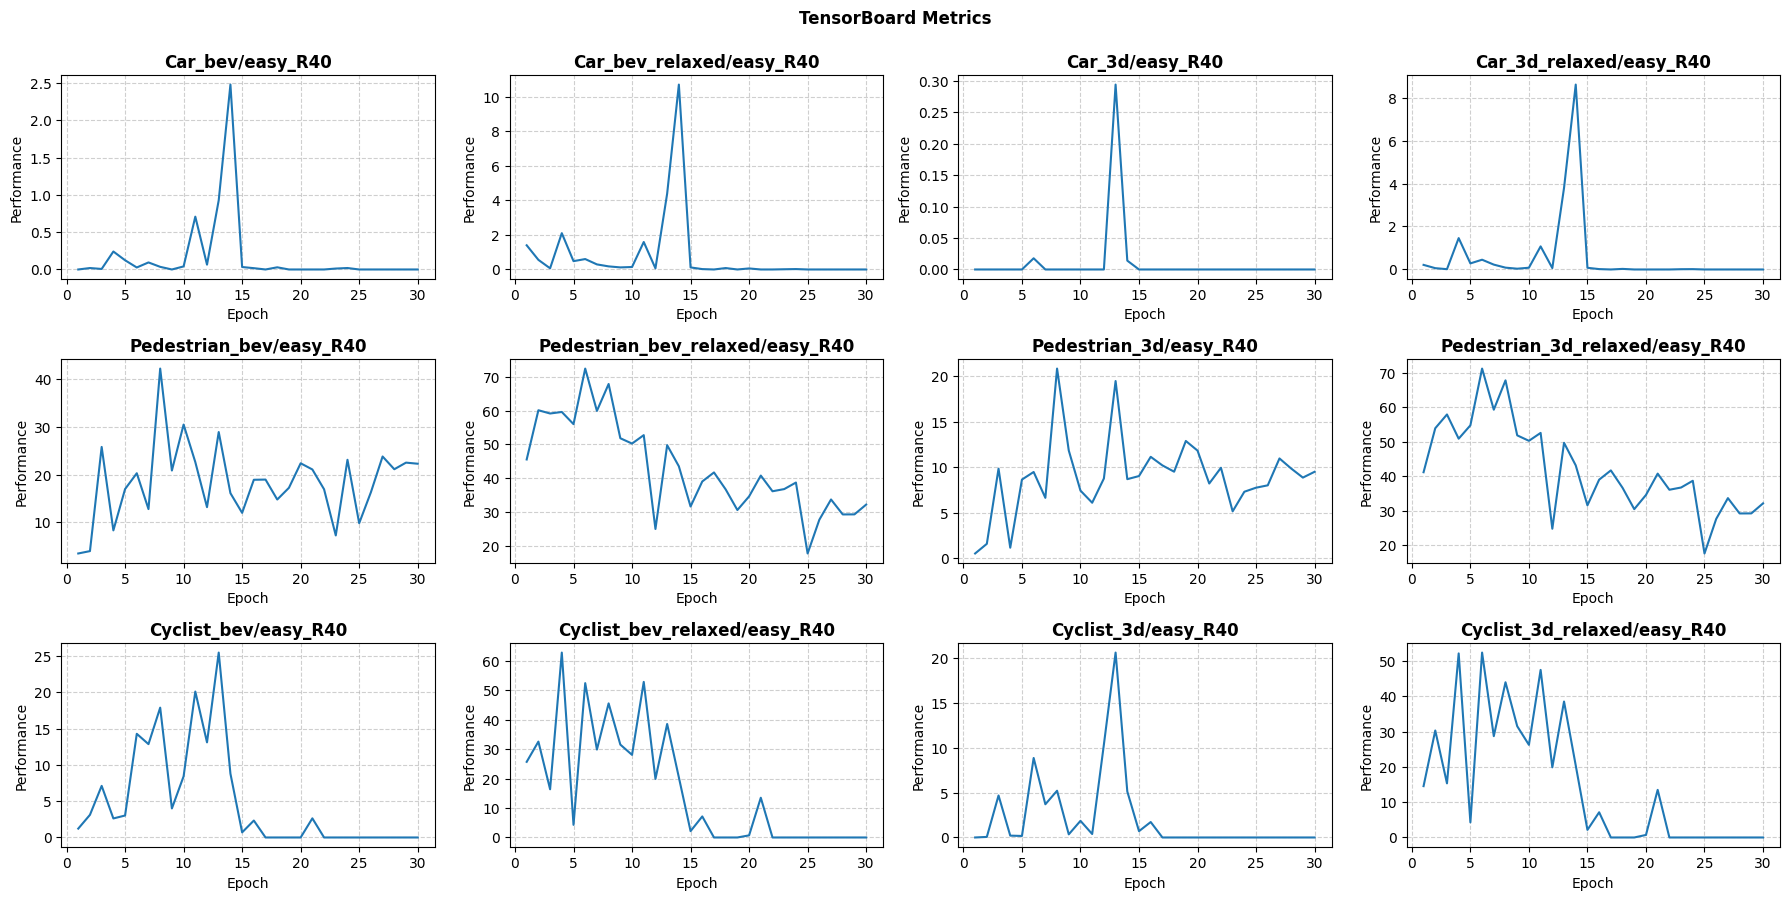

In [9]:
print_tb(log_test["S_F_def"]["E"])

In [10]:
#print_tb(log_test["S_F_ftd"]["K"])

In [11]:
#print_tb(log_test["S_F_ftd"]["N"])

In [12]:
#print_tb(log_test["S_F_ftd"]["E"])

## SECOND (TENT)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

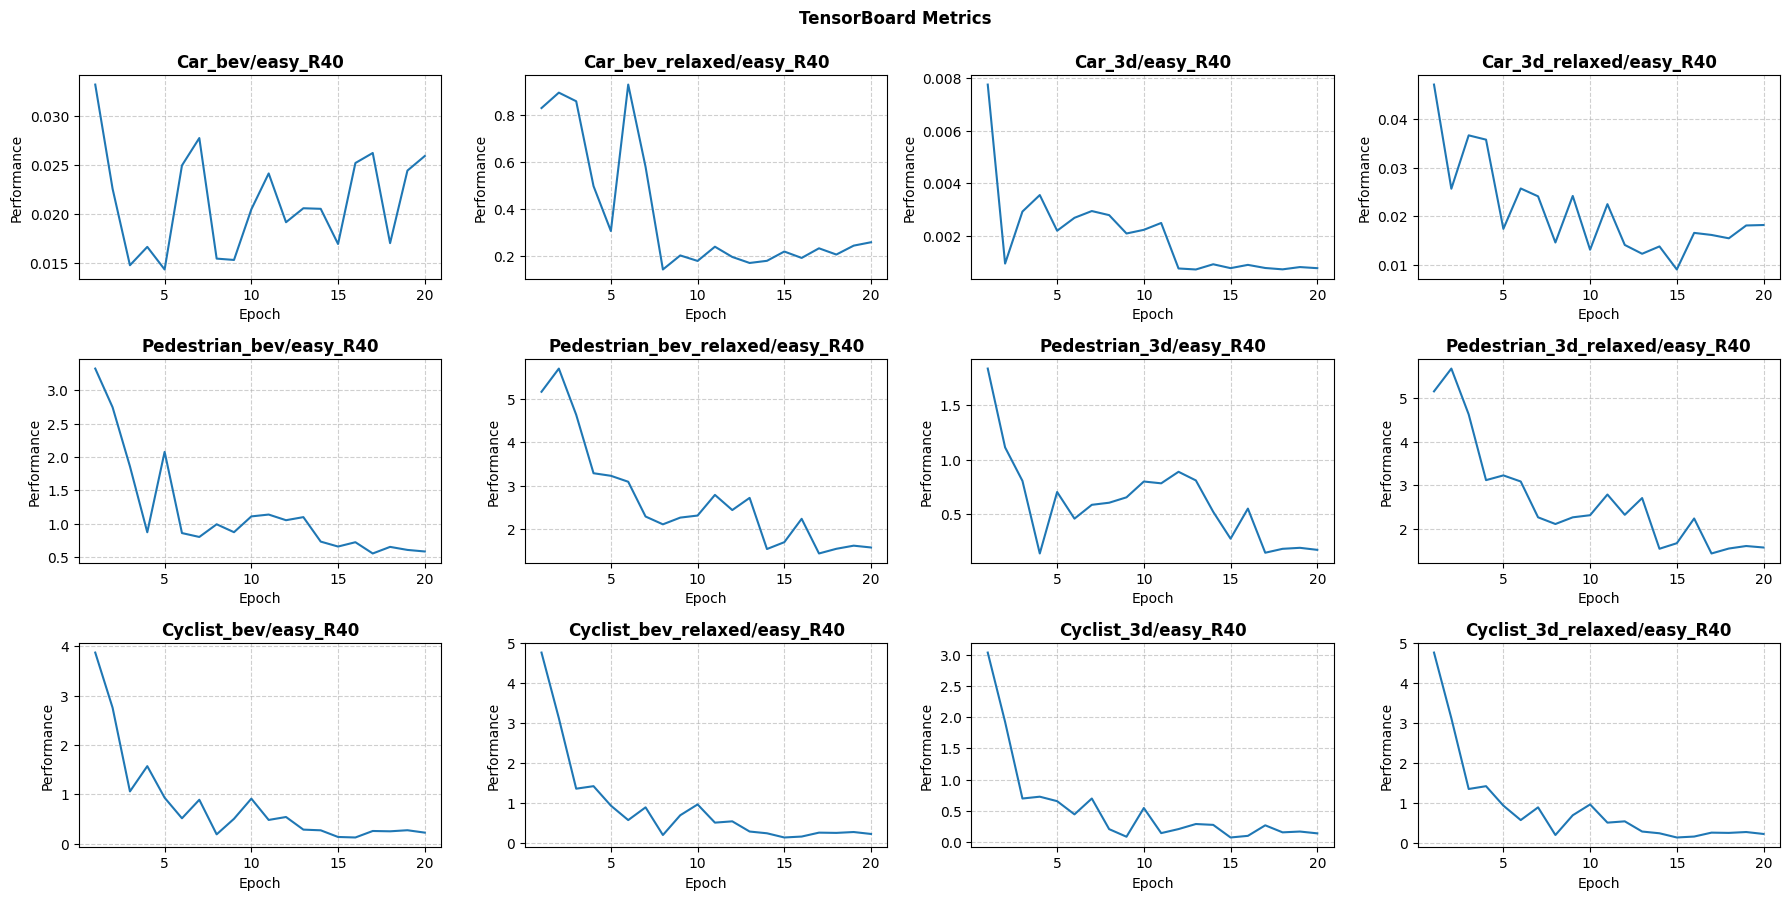

In [13]:
print_tb(log_test["S_T_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'mAP', 'NDS']


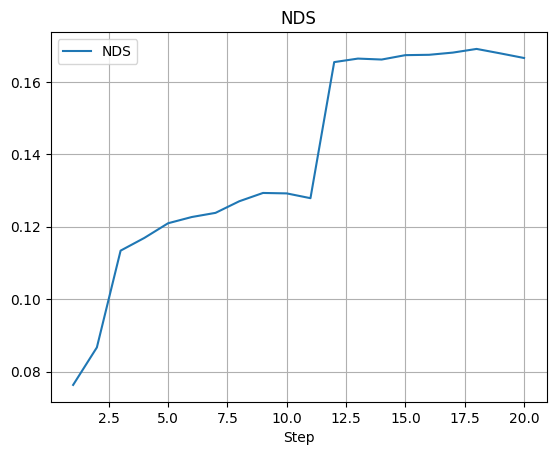

In [14]:
print_tb(log_test["S_T_ftd"]["N"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

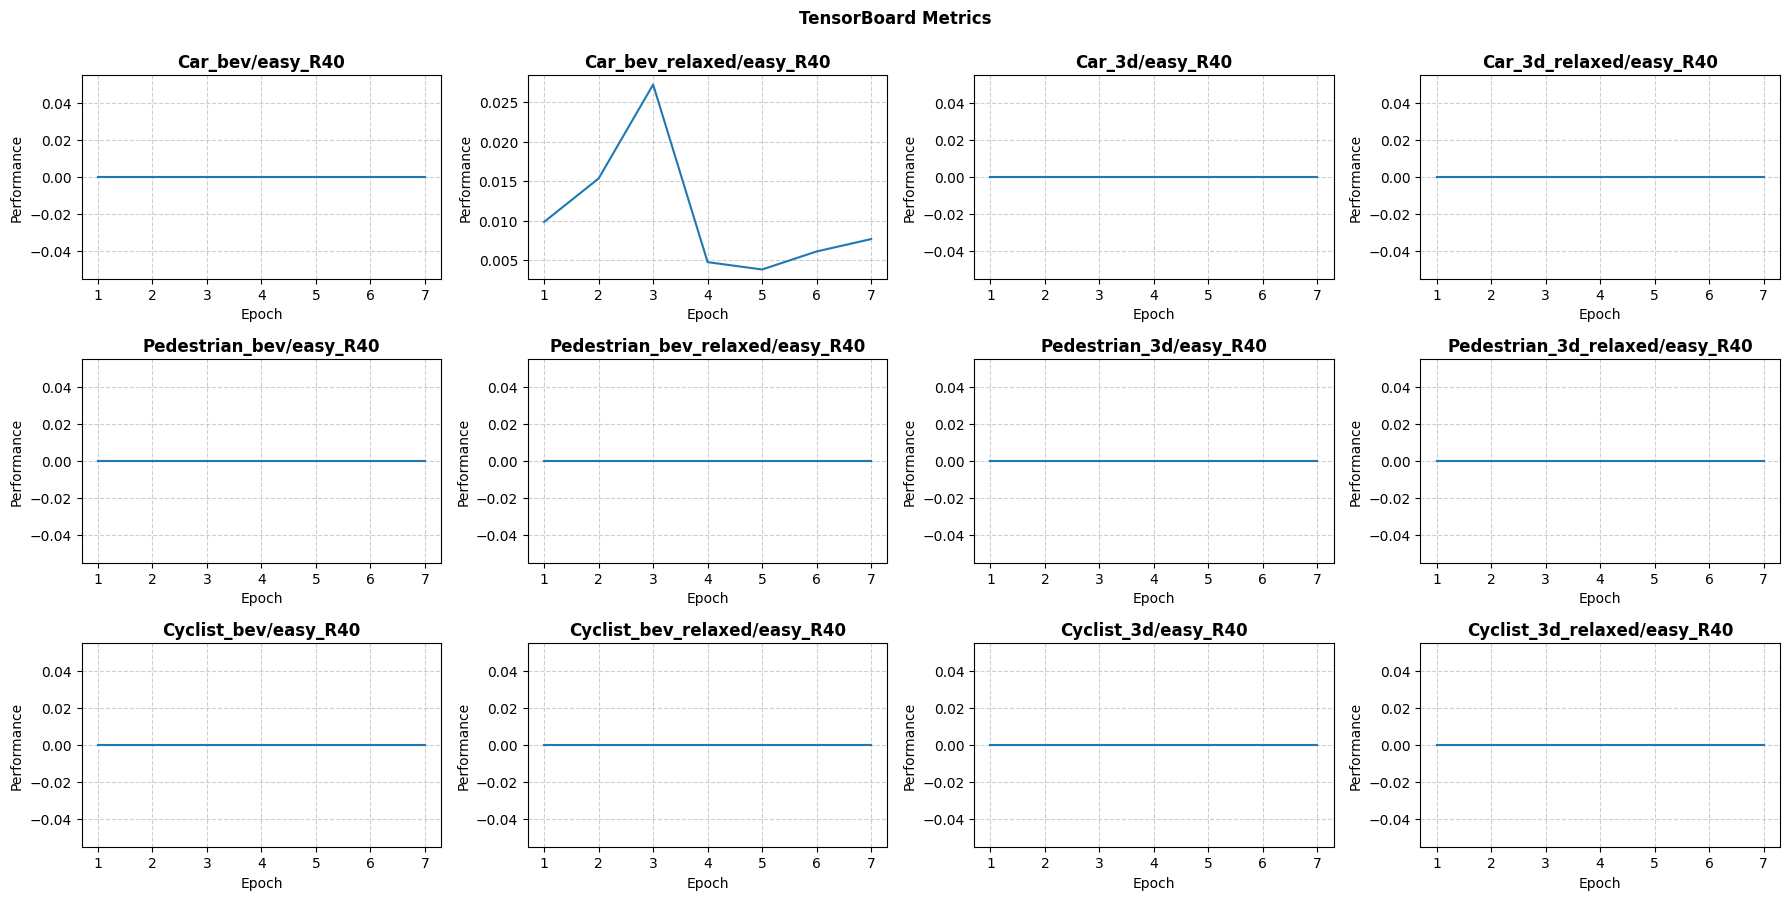

In [15]:
print_tb(log_test["S_T_ftd"]["E"])

## POINTPILLARS (DEFAULT)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

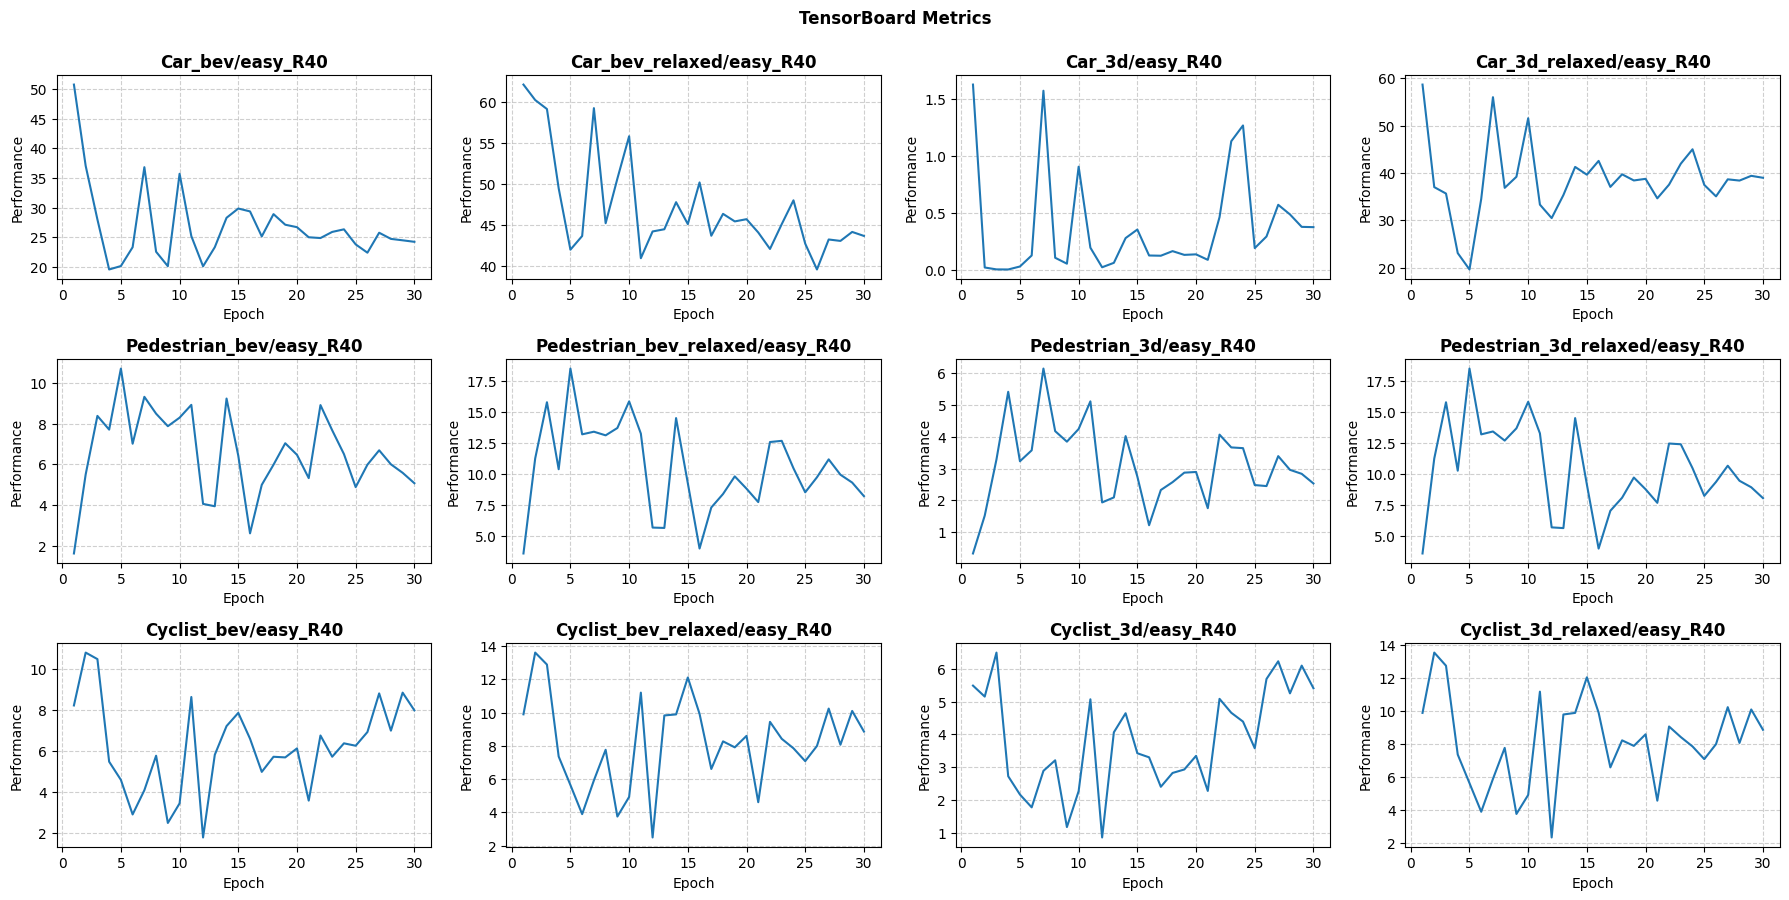

In [16]:
print_tb(log_test["P_D_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'mAP', 'NDS']


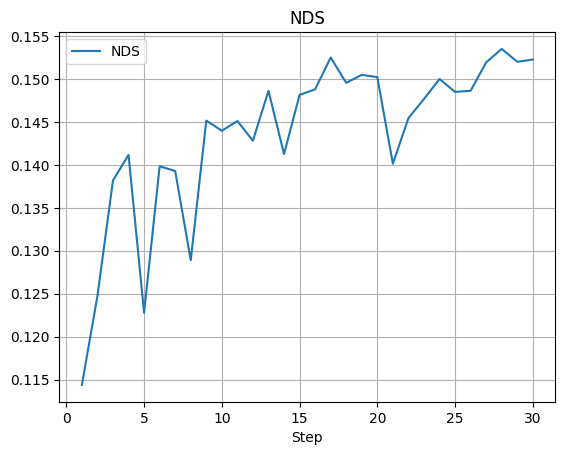

In [17]:
print_tb(log_test["P_D_ftd"]["N"])

In [12]:
print_tb(log_test["P_D_ftd"]["E"])

DirectoryDeletedError: Directory /OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_E/default/eval/eval_all_default/default/tensorboard_val has been permanently deleted

## POINTPILLARS (TENT)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

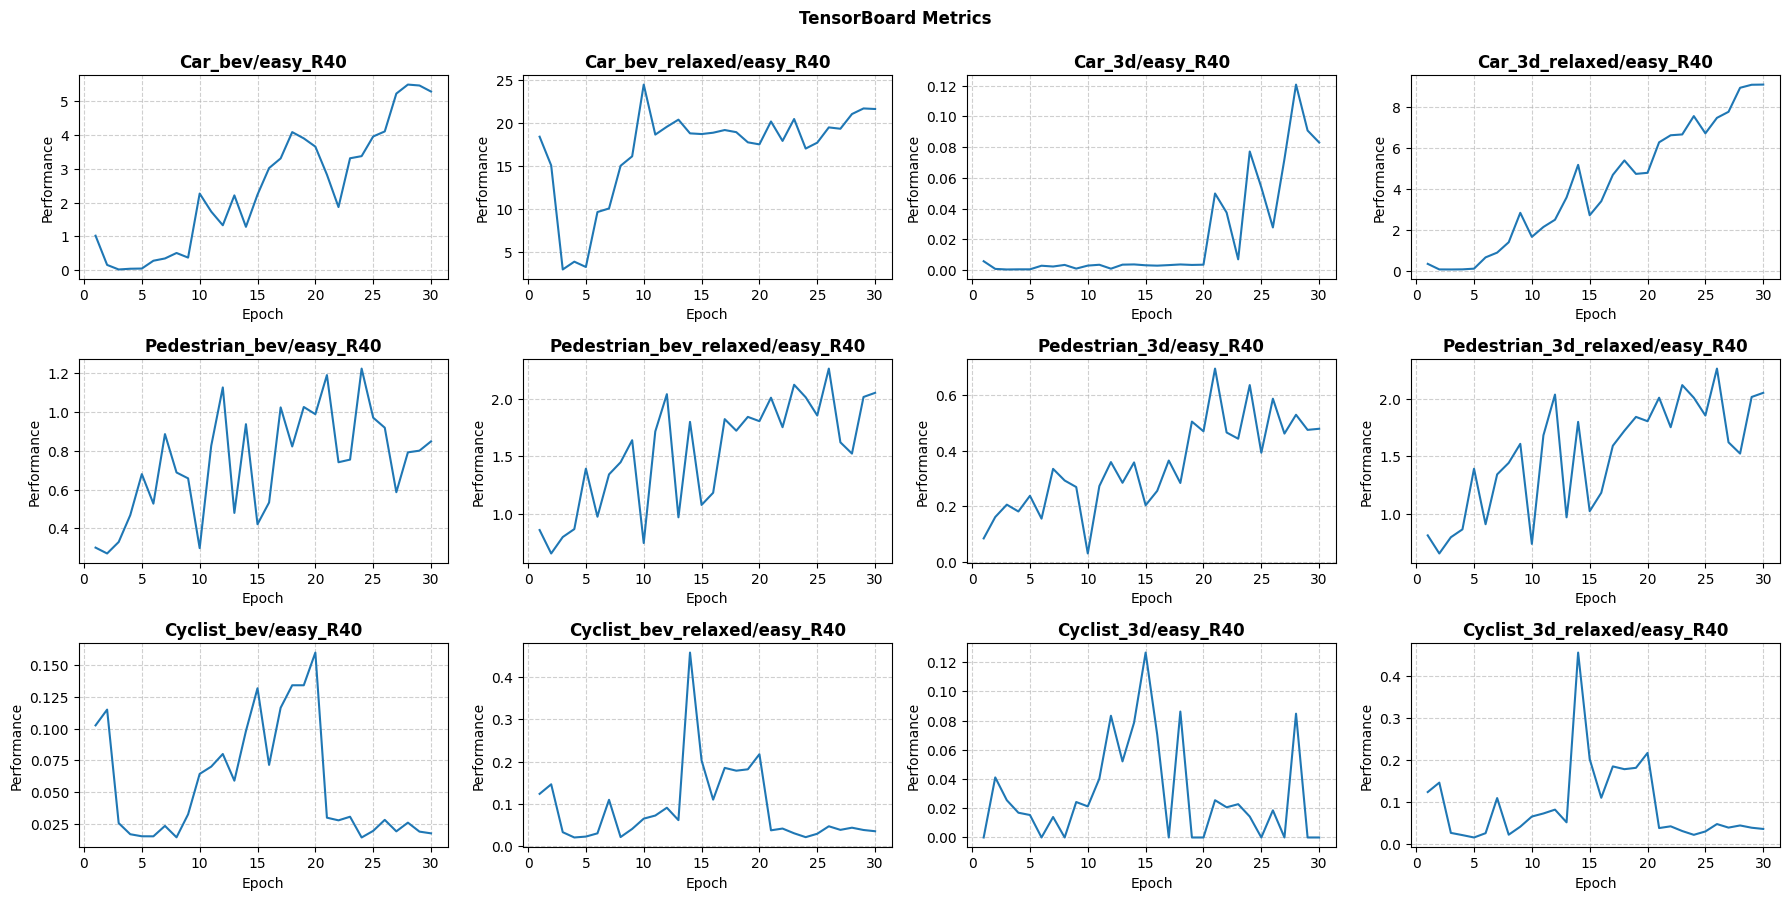

In [19]:
print_tb(log_test["P_T_ftd"]["K"])

In [6]:
print_tb(log_test["P_T_ftd"]["N"])

2026-08-14 12:53:16.713033: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-14 12:53:17.482108: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


DirectoryDeletedError: Directory /OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/T/P_T_N/default/eval/eval_all_default/default/tensorboard_val_all has been permanently deleted

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

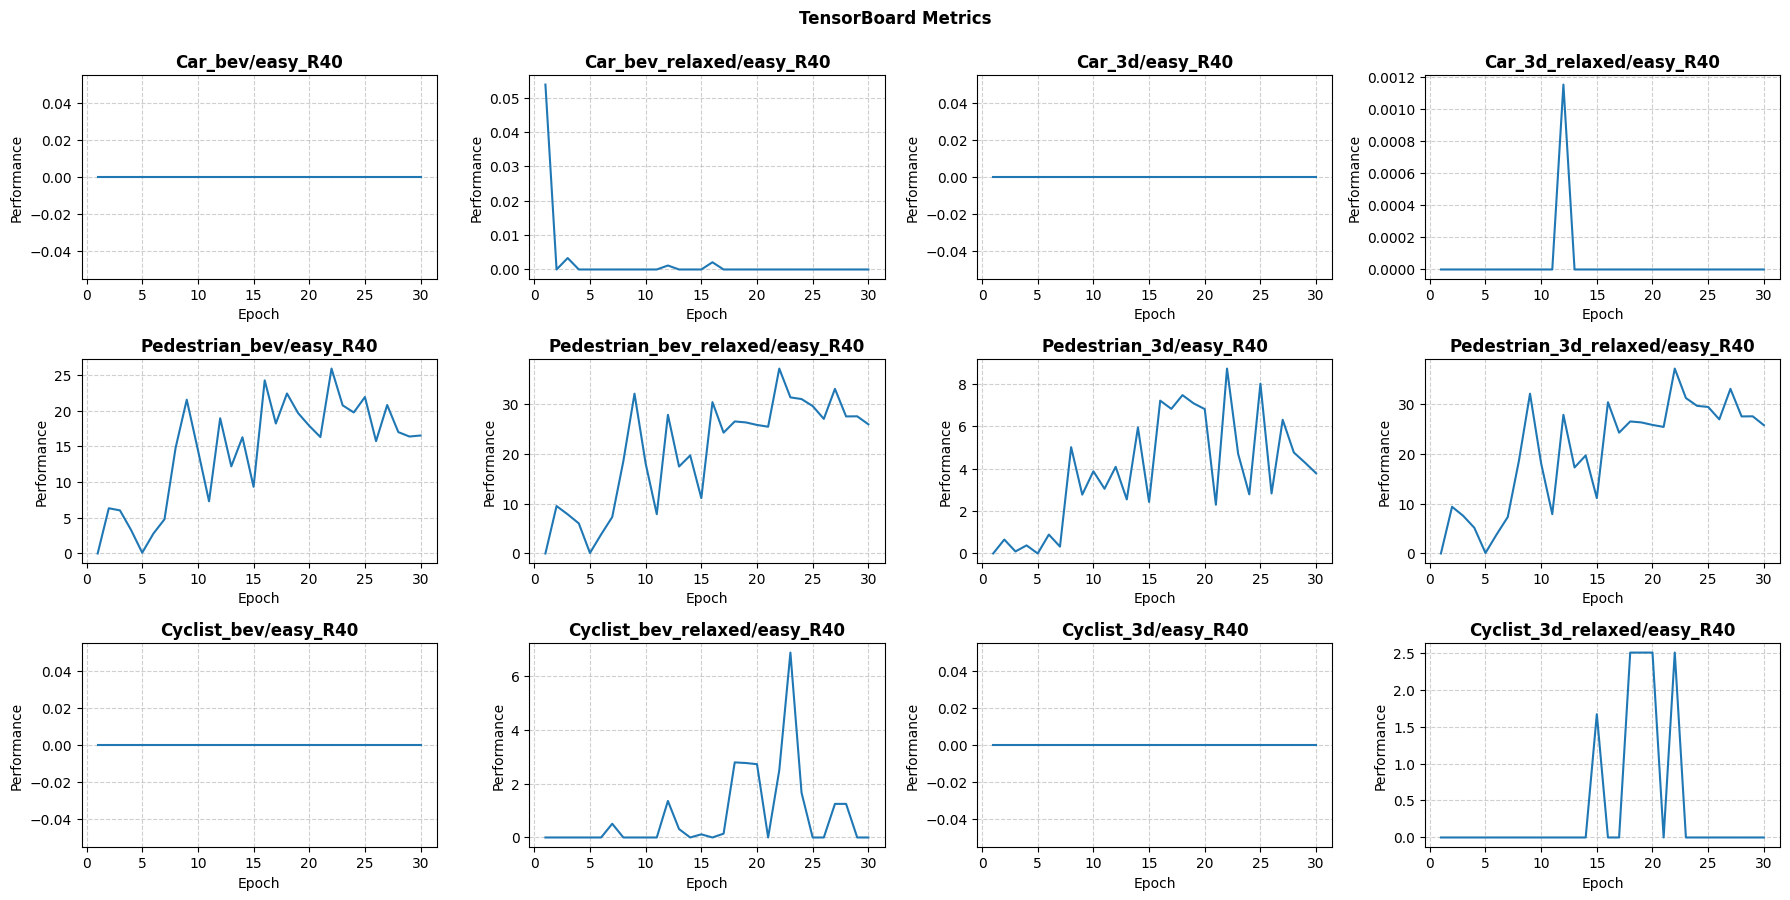

In [7]:
print_tb(log_test["P_T_ftd"]["E"])